# Gaussian Process Regression for Reconstructing Missing Values in Sensor Time Series
## Tidal water-level case study: Bang Pakong (Marine Department station), 2019–2026

This notebook reproduces every step and every figure of the paper, starting from the raw workbook `Clean_BangPaKong 2.xlsx`:

1. Load data → 2. Quality control → 3. Hourly series and tidal harmonic analysis → 4. Daily mean water level (DMWL)
5. Models: Standard (St), Kalman time-varying seasonal (TVS), GP (Matérn 3/2, Xu et al. 2024), GP-2M-SA
6. Full-record fits (Table I) and kernel diagnostics (Figs. 1–2)
7. Withheld-data gap experiments, 26 cases (Table II, Fig. 3) — **the slowest step (about 45–75 min on a standard Colab CPU)**
8. Reconstruction of the 2021 gap (Fig. 4) and hourly reconstruction (Fig. 5)

In [1]:
# ---------- 0. Setup ----------
import os, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy.optimize import minimize
from scipy.linalg import cho_factor, cho_solve
warnings.filterwarnings('ignore')
plt.rcParams.update({'figure.dpi': 110, 'font.size': 9, 'axes.spines.top': False, 'axes.spines.right': False})
COL = {'LI': '#8c8c8c', 'St': '#1f4e9c', 'TVS': '#9467bd', 'GP': '#c0392b', 'GP-2M-SA': '#2e7d32'}

## 1. Load the data
The workbook must be in the Colab working folder (`/content`). If it is not there, an upload button appears.

In [2]:
import glob
found = sorted(glob.glob('/content/Clean_BangPaKong*.xlsx') + glob.glob('Clean_BangPaKong*.xlsx'))
if found:
    DATA_FILE = found[0]
else:                                   # no workbook yet: show an upload button
    from google.colab import files
    uploaded = files.upload()
    DATA_FILE = next(iter(uploaded))
print('Reading', DATA_FILE)

raw = pd.read_excel(DATA_FILE)
raw.columns = ['t', 'h']
raw['t'] = pd.to_datetime(raw['t'])
print(raw.shape)
print('Span:', raw.t.min(), 'to', raw.t.max())
raw.head()

Reading /content/Clean_BangPaKong (2).xlsx
(353644, 2)
Span: 2019-05-07 16:48:00 to 2026-06-23 15:45:00


,t,h
0,2019-05-07 16:48:00,2.68
1,2019-05-07 17:03:00,2.88
2,2019-05-07 17:18:00,3.06
3,2019-05-07 17:33:00,3.23
4,2019-05-07 17:49:00,3.38


## 2. Quality control of the 10-min record

In [3]:
qc = {'raw_records': len(raw)}
g = raw.groupby('t').h.agg(['median', 'min', 'max', 'count'])
qc['duplicate_timestamps'] = int((g['count'] > 1).sum())
qc['duplicate_readings_merged'] = int(len(raw) - len(g))
bad_dup = (g['max'] - g['min']) > 0.10                     # duplicates that disagree
qc['conflicting_duplicates_removed'] = int(bad_dup.sum())
s = g.loc[~bad_dup, 'median']
z = s <= 0;       qc['zero_values_removed'] = int(z.sum());  s = s[~z]
hi = s >= 5.60;   qc['stuck_high_values_removed'] = int(hi.sum()); s = s[~hi]
run_id = (s.diff() != 0).cumsum()                            # flat-line runs >= 3 h
run_len = s.groupby(run_id).transform(lambda x: (x.index[-1] - x.index[0]).total_seconds() / 3600)
fl = run_len >= 3; qc['flatline_values_removed'] = int(fl.sum()); s = s[~fl]
qc['spikes_removed'] = 0
for it in range(2):                                          # Hampel-type spike filter
    dev = s - s.rolling('70min', center=True, min_periods=3).median()
    sp = dev.abs() > 0.25
    qc['spikes_removed'] += int(sp.sum()); s = s[~sp]
qc['clean_records'] = len(s)
clean10 = s
pd.Series(qc, name='count').to_frame()

,count
raw_records,353644
duplicate_timestamps,665
duplicate_readings_merged,974
conflicting_duplicates_removed,1
zero_values_removed,38
stuck_high_values_removed,563
flatline_values_removed,608
spikes_removed,248
clean_records,351212


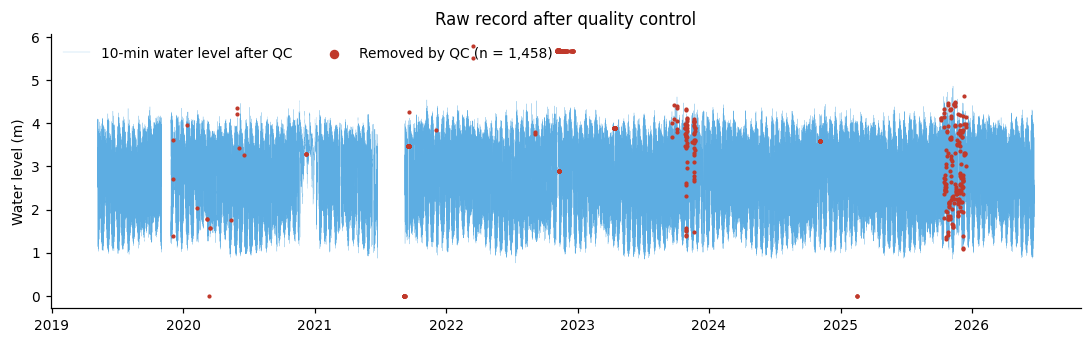

In [4]:
removed = raw.drop_duplicates('t'); removed = removed[~removed.t.isin(clean10.index)]
s_plot = clean10.copy(); brk = s_plot.index.to_series().diff() > pd.Timedelta('1h'); s_plot[brk[brk].index] = np.nan
fig, ax = plt.subplots(figsize=(10, 3.2))
ax.plot(s_plot.index, s_plot.values, lw=0.15, color='#5dade2', label='10-min water level after QC')
ax.scatter(removed.t, removed.h, s=3, color='#c0392b', zorder=3, label=f'Removed by QC (n = {len(removed):,})')
ax.set_ylabel('Water level (m)'); ax.legend(loc='upper left', ncol=2, frameon=False, markerscale=3)
ax.set_title('Raw record after quality control')
plt.tight_layout(); plt.show()

## 3. Hourly series and tidal harmonic analysis

In [5]:
# Hourly values: linear interpolation between neighbouring readings no more than 30 min apart
grid = pd.date_range(clean10.index[0].ceil('h'), clean10.index[-1].floor('h'), freq='h')
ts = clean10.index.as_unit('ns').asi8; tg = grid.as_unit('ns').asi8
idx = np.clip(np.searchsorted(ts, tg), 1, len(ts) - 1)
t0, t1 = ts[idx - 1], ts[idx]; y0, y1 = clean10.values[idx - 1], clean10.values[idx]
exact = t1 == tg
val = np.where(exact, y1, y0 + (tg - t0) / np.maximum(t1 - t0, 1) * (y1 - y0))
ok = ((t1 - t0) <= 30 * 60 * 1e9) | exact
hourly = pd.Series(np.where(ok, val, np.nan), grid)
print(f'Hourly grid: {len(hourly):,} hours, missing {hourly.isna().sum():,} ({100*hourly.isna().mean():.1f} %)')

# Tidal constituents: speed (deg/h) and nodal-correction type
CONST = {
 '2Q1':(12.8542862,'O1'),'Q1':(13.3986609,'O1'),'RHO1':(13.4715145,'O1'),'O1':(13.9430356,'O1'),
 'NO1':(14.4966939,'M1'),'P1':(14.9589314,None),'S1':(15.0,None),'K1':(15.0410686,'K1'),
 'J1':(15.5854433,'J1'),'OO1':(16.1391017,'OO1'),
 '2N2':(27.8953548,'M2'),'MU2':(27.9682084,'M2'),'N2':(28.4397295,'M2'),'NU2':(28.5125831,'M2'),
 'M2':(28.9841042,'M2'),'LAM2':(29.4556253,'M2'),'L2':(29.5284789,'M2'),'T2':(29.9589333,None),
 'S2':(30.0,None),'K2':(30.0821373,'K2'),'2SM2':(31.0158958,'M2'),
 'MO3':(42.9271398,'MO3'),'M3':(43.4761563,'M3'),'MK3':(44.0251729,'MK3'),'SK3':(45.0410686,'K1'),
 'MN4':(57.4238337,'M4'),'M4':(57.9682084,'M4'),'MS4':(58.9841042,'M2'),'MK4':(59.0662415,'MK3'),
 'S4':(60.0,None),'M6':(86.9523127,'M6'),'2MS6':(87.9682084,'M4'),'M8':(115.9364166,'M8')}
NAMES = list(CONST)
T0 = pd.Timestamp('2020-01-01')

def nodal(t):
    T = (t.to_julian_date().values - 2451545.0) / 36525.0
    N = np.deg2rad(125.04452 - 1934.136261 * T)
    c, s_, c2, s2 = np.cos(N), np.sin(N), np.cos(2*N), np.sin(2*N)
    fM2, uM2 = 1.0004 - 0.0373*c + 0.0002*c2, np.deg2rad(-2.14*s_)
    fO1, uO1 = 1.0089 + 0.1871*c - 0.0147*c2, np.deg2rad(10.80*s_ - 1.34*s2)
    fK1, uK1 = 1.0060 + 0.1150*c - 0.0088*c2, np.deg2rad(-8.86*s_ + 0.68*s2)
    fK2, uK2 = 1.0246 + 0.2863*c + 0.0083*c2, np.deg2rad(-17.74*s_ + 0.68*s2)
    fJ1, uJ1 = 1.0129 + 0.1676*c - 0.0170*c2, np.deg2rad(-12.94*s_ + 1.34*s2)
    fOO1, uOO1 = 1.1027 + 0.6504*c + 0.0317*c2, np.deg2rad(-36.68*s_ + 4.02*s2)
    one, zero = np.ones_like(c), np.zeros_like(c)
    return {None:(one,zero),'M2':(fM2,uM2),'O1':(fO1,uO1),'K1':(fK1,uK1),'K2':(fK2,uK2),'J1':(fJ1,uJ1),
            'OO1':(fOO1,uOO1),'M1':(one,zero),'M4':(fM2**2,2*uM2),'M6':(fM2**3,3*uM2),'M8':(fM2**4,4*uM2),
            'MK3':(fM2*fK1,uM2+uK1),'MO3':(fM2*fO1,uM2+uO1),'M3':(fM2**1.5,1.5*uM2)}

def tide_design(t):
    th = (t - T0).total_seconds().values / 3600.0
    nd = nodal(t); cols = []
    for n in NAMES:
        w, typ = CONST[n]; f, u = nd[typ]; arg = np.deg2rad(w) * th + u
        cols += [f * np.cos(arg), f * np.sin(arg)]
    return np.column_stack(cols)

def tide_fit(t, y):
    X = np.column_stack([np.ones(len(t)), tide_design(t)])
    return np.linalg.lstsq(X, y, rcond=None)[0]

def tide_predict(t, coef, with_mean=False):
    return (coef[0] if with_mean else 0.0) + tide_design(t) @ coef[1:]

ho = hourly.dropna()
tcoef = tide_fit(ho.index, ho.values)
res_h = ho - tide_predict(ho.index, tcoef, with_mean=True)
amp = pd.DataFrame({'constituent': NAMES, 'amplitude_m': np.hypot(tcoef[1::2], tcoef[2::2])}).sort_values('amplitude_m', ascending=False)
tt = amp.set_index('constituent').amplitude_m
print(f'Z0 = {tcoef[0]:.3f} m; variance explained by tides = {100*(1 - res_h.var()/ho.var()):.1f} %')
print(f'Form factor F = (K1+O1)/(M2+S2) = {(tt.K1 + tt.O1)/(tt.M2 + tt.S2):.2f}')
amp.head(8).round(3)

Hourly grid: 62,495 hours, missing 4,010 (6.4 %)
Z0 = 2.819 m; variance explained by tides = 94.7 %
Form factor F = (K1+O1)/(M2+S2) = 1.28


,constituent,amplitude_m
7,K1,0.652
14,M2,0.563
3,O1,0.416
18,S2,0.272
5,P1,0.181
19,K2,0.108
12,N2,0.088
1,Q1,0.075


## 4. Daily mean water level (DMWL)
Daily mean of the non-tidal residual plus Z0; days with fewer than 18 valid hours are missing.

In [6]:
cnt = res_h.resample('D').count()
full_days = pd.date_range(hourly.index[0].normalize(), hourly.index[-1].normalize(), freq='D')
dm = (res_h.resample('D').mean() + tcoef[0]).reindex(full_days)
cnt = cnt.reindex(full_days).fillna(0)
daily = pd.DataFrame({'dmwl': dm.where(cnt >= 18), 'hours': cnt})
m_ = daily.dmwl.isna(); blk = (m_ != m_.shift()).cumsum()[m_]
gaps = daily[m_].groupby(blk).apply(lambda d: pd.Series({'start': d.index[0], 'end': d.index[-1], 'days': len(d)}))
gaps = gaps.sort_values('days', ascending=False).reset_index(drop=True)
print(f'{len(daily):,} days: {daily.dmwl.notna().sum():,} observed, {daily.dmwl.isna().sum()} missing')
gaps.head(6)

2,605 days: 2,412 observed, 193 missing


,start,end,days
0,2021-06-25,2021-09-07,75
1,2020-11-27,2021-01-04,39
2,2019-11-03,2019-11-27,25
3,2022-11-05,2022-11-09,5
4,2021-06-10,2021-06-13,4
5,2021-01-09,2021-01-12,4


## 5. Models
* **St**: trend + constant annual and semiannual harmonics (OLS; rate uncertainty from a Gauss–Markov + white-noise likelihood)
* **TVS**: random-walk seasonal coefficients + AR(1) noise, Kalman filter and RTS smoother (Bennett-type)
* **GP**: $y=h(t)^\top\beta+f(t)+\varepsilon$, $\beta$ by GLS, kernel hyperparameters by maximum marginal likelihood with analytic gradients

In [11]:
def tyears(ix): return (ix - T0).days.values / 365.25

def basis(t, harm=(1,)):
    cols = [np.ones_like(t), t]
    for k in harm: cols += [np.sin(2*np.pi*k*t), np.cos(2*np.pi*k*t)]
    return np.column_stack(cols)

def _m32(r, lp):
    sf2, ell = np.exp(lp[0]), np.exp(lp[1]); a = np.sqrt(3)*r/ell; e = np.exp(-a); K = sf2*(1+a)*e
    return K, [K, sf2*a*a*e]
def _exp(r, lp):
    sf2, tau = np.exp(lp[0]), np.exp(lp[1]); K = sf2*np.exp(-r/tau); return K, [K, K*r/tau]
def _qp(r, lp, P=1.0):
    sf2, l1, l2 = np.exp(lp[0]), np.exp(lp[1]), np.exp(lp[2]); s2 = np.sin(np.pi*r/P)**2
    K = sf2*np.exp(-2*s2/l1**2 - r**2/(2*l2**2)); return K, [K, K*4*s2/l1**2, K*r**2/l2**2]
def _sum(*parts):
    def f(r, lp):
        K, G, i = 0, [], 0
        for fn, n in parts:
            k, gg = fn(r, lp[i:i+n]); K = K + k; G += gg; i += n
        return K, G
    return f

KERNELS = {  # name: (kernel, parameter names, initial log-parameters, harmonics in the basis)
 'GP':       (_m32, ['sf2','ell_yr'], [np.log(0.01), np.log(0.05)], (1,)),
 'GPM12':    (_exp, ['sf2','ell_yr'], [np.log(0.01), np.log(0.01)], (1,)),
 'GPQP':     (_sum((_m32,2),(_qp,3)), ['sf2_m32','ell_m32_yr','sf2_qp','lp_qp','ld_qp_yr'],
              [np.log(0.008), np.log(0.01), np.log(0.004), np.log(0.8), np.log(3.0)], (1,)),
 'GP2M32SA': (_sum((_m32,2),(_m32,2)), ['sf2_short','ell_short_yr','sf2_long','ell_long_yr'],
              [np.log(0.007), np.log(0.005), np.log(0.002), np.log(0.1)], (1,2)),
 'StGM':     (_exp, ['sf2','tau_yr'], [np.log(0.01), np.log(0.01)], (1,2)),
}

class GPModel:
    def __init__(self, kind='GP'):
        self.kind = kind; self.kf, self.pnames, self.p0, self.harm = KERNELS[kind]
    def _prep(self, lp, R):
        K, G = self.kf(R, lp[:-1]); sn2 = np.exp(lp[-1]); K = K.copy()
        K[np.diag_indices_from(K)] += sn2 + 1e-8
        return K, G + [sn2*np.eye(len(R))]
    def _nll(self, lp, y, H, R):
        K, G = self._prep(lp, R)
        try: c = cho_factor(K, lower=True)
        except np.linalg.LinAlgError: return 1e10, np.zeros_like(lp)
        KiH = cho_solve(c, H); beta = np.linalg.solve(H.T @ KiH, KiH.T @ y); res = y - H @ beta
        alpha = cho_solve(c, res)
        nll = 0.5*res @ alpha + np.log(np.diag(c[0])).sum() + 0.5*len(y)*np.log(2*np.pi)
        W = np.outer(alpha, alpha) - cho_solve(c, np.eye(len(y)))
        return nll, np.array([-0.5*np.sum(W*g) for g in G])
    def fit(self, t, y, lp0=None):
        self.t, self.y = t, y; H = basis(t, self.harm); R = np.abs(t[:, None] - t[None, :])
        start = np.r_[self.p0, np.log(0.003)] if lp0 is None else np.asarray(lp0)
        o = minimize(self._nll, start, args=(y, H, R), jac=True,
                     method='L-BFGS-B', bounds=[(-14, 4)]*(len(self.p0)+1))
        self.lp, self.nll = o.x, o.fun
        K, _ = self._prep(o.x, R); self.c = cho_factor(K, lower=True)
        self.KiH = cho_solve(self.c, H); self.Ainv = np.linalg.inv(H.T @ self.KiH)
        self.beta = self.Ainv @ (self.KiH.T @ y); self.alpha = cho_solve(self.c, y - H @ self.beta); self.H = H
        self.params = dict(zip(self.pnames + ['sn2'], np.exp(o.x))); self.k = len(o.x) + H.shape[1]
        return self
    def predict(self, ts):
        Hs = basis(ts, self.harm); Ks, _ = self.kf(np.abs(ts[:, None] - self.t[None, :]), self.lp[:-1])
        mean = Hs @ self.beta + Ks @ self.alpha
        kss, _ = self.kf(np.zeros(1), self.lp[:-1]); V = cho_solve(self.c, Ks.T)
        var = kss[0] - np.einsum('ij,ji->i', Ks, V)
        Rm = Hs - Ks @ self.KiH; var = var + np.einsum('ij,jk,ik->i', Rm, self.Ainv, Rm)
        return mean, np.sqrt(np.maximum(var, 0) + self.params['sn2'])
    def rate(self): return 1000*self.beta[1], 1000*np.sqrt(self.Ainv[1, 1])
    def aic(self): return 2*self.nll + 2*self.k
    def loo_rmse(self):
        K, _ = self._prep(self.lp, np.abs(self.t[:, None] - self.t[None, :]))
        S = K + self.H @ (1e4*np.eye(self.H.shape[1])) @ self.H.T; Si = np.linalg.inv(S)
        r = (Si @ self.y) / np.diag(Si); return 100*np.sqrt(np.mean(r**2)), r

class StModel:
    harm = (1, 2)
    def fit(self, t, y):
        H = basis(t, self.harm); self.beta = np.linalg.lstsq(H, y, rcond=None)[0]; self.H, self.y = H, y; return self
    def predict(self, ts): return basis(ts, self.harm) @ self.beta
    def loo(self):
        hat = self.H @ np.linalg.solve(self.H.T @ self.H, self.H.T); e = self.y - hat @ self.y
        r = e / (1 - np.diag(hat)); return 100*np.sqrt(np.mean(r**2)), e

class TVSModel:
    harm = (1, 2)
    def _kf(self, lp, t, y, smooth=False):
        q1, q2, r = np.exp(lp[:3]); phi = np.tanh(lp[3]); qc = np.exp(lp[4])
        n, m = len(t), 7
        F = np.eye(m); F[-1, -1] = phi; Q = np.diag([0, 0, q1, q1, q2, q2, qc])
        x = np.zeros(m); P = np.eye(m)*1e2; P[1, 1] = 1e1; P[-1, -1] = qc/(1 - phi**2)
        xf = np.zeros((n, m)); Pf = np.zeros((n, m, m)); xp = np.zeros((n, m)); Pp = np.zeros((n, m, m))
        Hs = np.column_stack([basis(t, self.harm), np.ones(n)]); nll = 0.0
        for i in range(n):
            if i > 0: x = F @ x; P = F @ P @ F.T + Q
            xp[i] = x; Pp[i] = P
            if not np.isnan(y[i]):
                h = Hs[i]; PH = P @ h; S = h @ PH + r; Kg = PH/S; inn = y[i] - h @ x
                x = x + Kg*inn; P = P - np.outer(Kg, PH)
                if i > 60: nll += 0.5*(np.log(2*np.pi*S) + inn**2/S)
            xf[i] = x; Pf[i] = P
        if not smooth: return nll
        xs, Ps = xf.copy(), Pf.copy()
        for i in range(n-2, -1, -1):
            J = Pf[i] @ F.T @ np.linalg.inv(Pp[i+1])
            xs[i] = xf[i] + J @ (xs[i+1] - xp[i+1]); Ps[i] = Pf[i] + J @ (Ps[i+1] - Pp[i+1]) @ J.T
        return xs, Ps, Hs
    def fit(self, t_all, y_all, x0=None):
        if x0 is None: x0 = np.r_[np.log([1e-7, 1e-8, 0.001]), np.arctanh(0.7), np.log(0.003)]
        o = minimize(self._kf, x0, args=(t_all, y_all), method='Nelder-Mead', options={'maxiter': 600, 'xatol': 1e-3, 'fatol': 1e-3})
        self.lp = o.x
        xs, Ps, Hs = self._kf(o.x, t_all, y_all, smooth=True); self.xs, self.Ps = xs, Ps
        self.mean = np.einsum('ij,ij->i', Hs, xs)
        self.params = {'q_annual': np.exp(o.x[0]), 'q_semiannual': np.exp(o.x[1]), 'phi_AR1': np.tanh(o.x[3])}
        return self
    def rate(self): return 1000*self.xs[-1, 1], 1000*np.sqrt(self.Ps[-1, 1, 1])
print('Models defined.')

Models defined.


## 6. Full-record fits — Table I

In [8]:
t_all = tyears(daily.index); y_all = daily.dmwl.values; obs = ~np.isnan(y_all)
t_obs, y_obs = t_all[obs], y_all[obs]
fits, rows = {}, []
tic = time.time()
st = StModel().fit(t_obs, y_obs); stgm = GPModel('StGM').fit(t_obs, y_obs); loo_st, res_st = st.loo()
rows.append(['St (GM noise)', *stgm.rate(), loo_st, stgm.aic()])
tvs = TVSModel().fit(t_all, y_all); fits['TVS'] = tvs
rows.append(['TVS (Kalman)', *tvs.rate(), np.nan, np.nan])
for k, lab in [('GP','GP, Matérn 3/2 (Xu et al.)'), ('GPM12','GP, Matérn 1/2'), ('GPQP','GP, Matérn 3/2 + QP'), ('GP2M32SA','GP-2M-SA')]:
    gm = GPModel(k).fit(t_obs, y_obs); fits[k] = gm
    rows.append([lab, *gm.rate(), gm.loo_rmse()[0], gm.aic()])
    print(f'{lab:28s} fitted ({time.time()-tic:.0f} s)')
table1 = pd.DataFrame(rows, columns=['Model', 'Rate (mm/yr)', '±1σ', 'LOO RMSE (cm)', 'AIC']).round(2)
print('TVS random-walk variances:', {k: f'{v:.1e}' for k, v in tvs.params.items()})
print('GP-2M-SA length scales (days):', round(fits['GP2M32SA'].params['ell_short_yr']*365.25, 2), round(fits['GP2M32SA'].params['ell_long_yr']*365.25, 2))
table1

GP, Matérn 3/2 (Xu et al.)   fitted (378 s)
GP, Matérn 1/2               fitted (525 s)
GP, Matérn 3/2 + QP          fitted (620 s)
GP-2M-SA                     fitted (881 s)
TVS random-walk variances: {'q_annual': '6.4e-16', 'q_semiannual': '1.3e-15', 'phi_AR1': '5.9e-01'}
GP-2M-SA length scales (days): 0.85 5.64


,Model,Rate (mm/yr),±1σ,LOO RMSE (cm),AIC
0,St (GM noise),2.46,1.81,9.56,-5441.32
1,TVS (Kalman),2.46,1.85,NaN,NaN
2,"GP, Matérn 3/2 (Xu et al.)",2.59,1.75,6.83,-5385.63
3,"GP, Matérn 1/2",2.58,1.97,6.81,-5415.64
4,"GP, Matérn 3/2 + QP",2.49,1.60,6.77,-5416.99
5,GP-2M-SA,2.44,2.20,6.67,-5480.87


## Figures 1 and 2 — the data and the kernel correlation functions

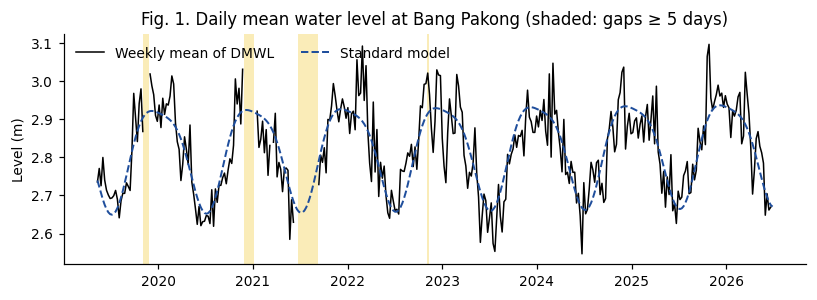

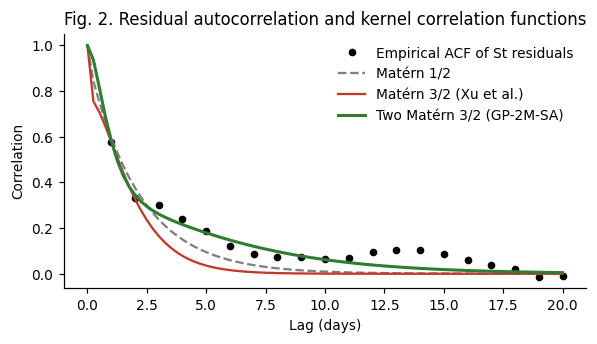

In [9]:
# Figure 1: weekly means of the DMWL with the Standard model and the longest gaps
wk = daily.dmwl.resample('W').agg(['mean', 'count']); wkm = wk['mean'].where(wk['count'] >= 4)
st_line = pd.Series(st.predict(t_all), daily.index).resample('W').mean()
fig, ax = plt.subplots(figsize=(7.5, 2.8))
for _, gp_ in gaps[gaps.days >= 5].iterrows():
    ax.axvspan(gp_.start, gp_.end + pd.Timedelta('1D'), color='#f7e08a', alpha=0.6, lw=0)
ax.plot(wkm.index, wkm.values, color='k', lw=1, label='Weekly mean of DMWL')
ax.plot(st_line.index, st_line.values, '--', color=COL['St'], lw=1.3, label='Standard model')
ax.set_ylabel('Level (m)'); ax.legend(frameon=False, ncol=2, loc='upper left')
ax.set_title('Fig. 1. Daily mean water level at Bang Pakong (shaded: gaps ≥ 5 days)')
plt.tight_layout(); plt.show()

# Figure 2: empirical ACF of St residuals vs correlation implied by fitted kernels
r_grid = y_all - st.predict(t_all); rc = r_grid - np.nanmean(r_grid); v0 = np.nanmean(rc*rc)
acf = np.array([np.nanmean(rc[:-k]*rc[k:])/v0 for k in range(1, 21)])
lags = np.arange(0, 20.01, 0.25); Y = 365.25
def rho(kind):
    gm = fits[kind]; K, _ = gm.kf(lags/Y, gm.lp[:-1]); K0, _ = gm.kf(np.zeros(1), gm.lp[:-1])
    out = K/(K0[0] + gm.params['sn2']); out[0] = 1; return out
fig, ax = plt.subplots(figsize=(5.5, 3.2))
ax.plot(range(1, 21), acf, 'o', color='k', ms=4, label='Empirical ACF of St residuals')
ax.plot(lags, rho('GPM12'), '--', color='gray', label='Matérn 1/2')
ax.plot(lags, rho('GP'), color=COL['GP'], label='Matérn 3/2 (Xu et al.)')
ax.plot(lags, rho('GP2M32SA'), color=COL['GP-2M-SA'], lw=2, label='Two Matérn 3/2 (GP-2M-SA)')
ax.set_xlabel('Lag (days)'); ax.set_ylabel('Correlation'); ax.legend(frameon=False)
ax.set_title('Fig. 2. Residual autocorrelation and kernel correlation functions')
plt.tight_layout(); plt.show()

## 7. Withheld-data gap experiments — Table II and Fig. 3
Every model, including its hyperparameters, is refitted on the remaining data in each of the 26 cases.
The optimizer starts from the full-record estimates to shorten the run. **This is still the slowest step.** Progress is printed after each case.

In [12]:
n = len(y_all); idx_d = daily.index
def make_cases():
    C = []
    for pct in (10, 20, 30, 40):
        L = int(round(n*pct/100))
        for cpos in (0.35, 0.65):
            s0 = int(n*cpos - L/2); m = np.zeros(n, bool); m[s0:s0+L] = True
            C.append(('A_interior_block', f'{pct}% block at {int(cpos*100)}%', m))
    for pct in (10, 20, 30, 40):
        L = int(round(n*pct/100)); m = np.zeros(n, bool); m[n-L:] = True
        C.append(('B_end_prediction', f'last {pct}%', m))
    for yr in (2020, 2022, 2023, 2024, 2025):
        C.append(('C1_JunSep_75d', f'{yr} Jun-Sep', np.asarray((idx_d >= f'{yr}-06-25') & (idx_d <= f'{yr}-09-07'))))
    for yr in (2021, 2022, 2023, 2024, 2025):
        C.append(('C2_NovJan_39d', f'{yr}/{yr+1} Nov-Jan', np.asarray((idx_d >= f'{yr}-11-27') & (idx_d <= f'{yr+1}-01-04'))))
    rng = np.random.default_rng(2024)
    for pct in (10, 20, 30, 40):
        m = np.zeros(n, bool)
        while m[obs].mean() < pct/100:
            L = rng.integers(1, 11); s0 = rng.integers(0, n-L); m[s0:s0+L] = True
        C.append(('D_scattered_1to10d', f'{pct}% scattered', m))
    return C
CASES = make_cases()

def rmse(a, b): return 100*np.sqrt(np.mean((a - b)**2))
# Hyperparameters are re-estimated in every case; the optimizer only starts from the full-record estimates to save time.
WARM = {'TVS': getattr(fits['TVS'], 'lp', None), 'GP': fits['GP'].lp, 'GP2M32SA': fits['GP2M32SA'].lp}
exp_rows, exp_preds = [], {}
tic = time.time()
for ci, (grp, lab, mask) in enumerate(CASES):
    test = mask & obs; train = obs & ~mask
    tt_, yt_, ts_, ys_ = t_all[train], y_all[train], t_all[test], y_all[test]
    pr = {'LI': np.interp(ts_, tt_, yt_), 'St': StModel().fit(tt_, yt_).predict(ts_)}
    pr['TVS'] = TVSModel().fit(t_all, np.where(train, y_all, np.nan), x0=WARM['TVS']).mean[test]
    cover = np.nan
    for k, name in (('GP', 'GP'), ('GP2M32SA', 'GP-2M-SA')):
        gm = GPModel(k).fit(tt_, yt_, lp0=WARM[k]); mu, sd = gm.predict(ts_); pr[name] = mu
        if name == 'GP-2M-SA': cover = 100*np.mean(np.abs(mu - ys_) <= 1.96*sd)
    for name, p in pr.items():
        exp_rows.append({'case': ci, 'group': grp, 'label': lab, 'model': name, 'RMSE_cm': rmse(p, ys_),
                         'cover95_GP2MSA': cover if name == 'GP-2M-SA' else np.nan})
    exp_preds[ci] = (idx_d[test], pr)
    print(f'[{ci+1:2d}/26] {grp:20s} {lab:22s} ' + '  '.join(f'{k}={rmse(v, ys_):5.2f}' for k, v in pr.items()) + f'   ({(time.time()-tic)/60:.1f} min)')
EXP = pd.DataFrame(exp_rows)
EXP.to_csv('gap_experiments.csv', index=False)

[ 1/26] A_interior_block     10% block at 35%       LI=13.46  St=10.85  TVS=10.53  GP=10.60  GP-2M-SA=10.46   (2.9 min)
[ 2/26] A_interior_block     10% block at 65%       LI=25.36  St= 8.93  TVS= 8.83  GP= 8.98  GP-2M-SA= 8.77   (5.5 min)
[ 3/26] A_interior_block     20% block at 35%       LI=14.51  St=10.27  TVS=10.23  GP=10.31  GP-2M-SA=10.21   (7.5 min)
[ 4/26] A_interior_block     20% block at 65%       LI=13.95  St= 8.74  TVS= 8.70  GP= 9.02  GP-2M-SA= 8.65   (9.5 min)
[ 5/26] A_interior_block     30% block at 35%       LI=14.53  St=10.37  TVS=10.34  GP=10.60  GP-2M-SA=10.32   (11.3 min)
[ 6/26] A_interior_block     30% block at 65%       LI=13.49  St= 9.76  TVS= 9.76  GP=10.09  GP-2M-SA= 9.74   (13.2 min)
[ 7/26] A_interior_block     40% block at 35%       LI=20.28  St=10.19  TVS=10.16  GP=10.40  GP-2M-SA=10.15   (14.7 min)
[ 8/26] A_interior_block     40% block at 65%       LI=13.23  St= 9.76  TVS= 9.75  GP=10.01  GP-2M-SA= 9.74   (16.3 min)
[ 9/26] B_end_prediction     last 10

95% interval coverage of GP-2M-SA (%):
group
A_interior_block      94.0
B_end_prediction      94.6
C1_JunSep_75d         98.1
C2_NovJan_39d         93.3
D_scattered_1to10d    93.8
Name: cover95_GP2MSA, dtype: float64


model,LI,St,TVS,GP,GP-2M-SA
group,,,,,
A_interior_block,16.10,9.86,9.79,10.00,9.76
B_end_prediction,19.89,9.98,10.06,10.28,9.99
C1_JunSep_75d,9.21,8.62,8.65,8.31,8.59
C2_NovJan_39d,12.92,9.59,9.53,10.01,9.54
D_scattered_1to10d,10.16,9.81,9.08,9.25,8.96
All 26 cases,13.83,9.58,9.45,9.60,9.40


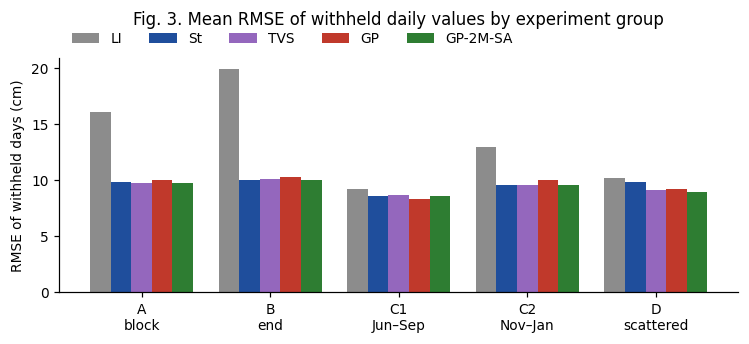

In [13]:
order = ['LI', 'St', 'TVS', 'GP', 'GP-2M-SA']
table2 = EXP.pivot_table(index='group', columns='model', values='RMSE_cm')[order]
table2.loc['All 26 cases'] = EXP.groupby('model').RMSE_cm.mean()[order]
print('95% interval coverage of GP-2M-SA (%):'); print(EXP.dropna(subset=['cover95_GP2MSA']).groupby('group').cover95_GP2MSA.mean().round(1))
display(table2.round(2))

groups = table2.index[:-1]; x = np.arange(len(groups)); w = 0.16
fig, ax = plt.subplots(figsize=(7, 3.2))
for i, k in enumerate(order):
    ax.bar(x + (i-2)*w, table2.loc[groups, k], w, color=COL[k], label=k)
lab_map = {'A_interior_block': 'A\nblock', 'B_end_prediction': 'B\nend', 'C1_JunSep_75d': 'C1\nJun–Sep', 'C2_NovJan_39d': 'C2\nNov–Jan', 'D_scattered_1to10d': 'D\nscattered'}
ax.set_xticks(x); ax.set_xticklabels([lab_map[g_] for g_ in groups])
ax.set_ylabel('RMSE of withheld days (cm)'); ax.legend(ncol=5, frameon=False, loc='lower left', bbox_to_anchor=(0, 1.0))
ax.set_title('Fig. 3. Mean RMSE of withheld daily values by experiment group', pad=22)
plt.tight_layout(); plt.show()

## 8. Reconstruction of the 2021 gap (Fig. 4) and hourly reconstruction (Fig. 5)

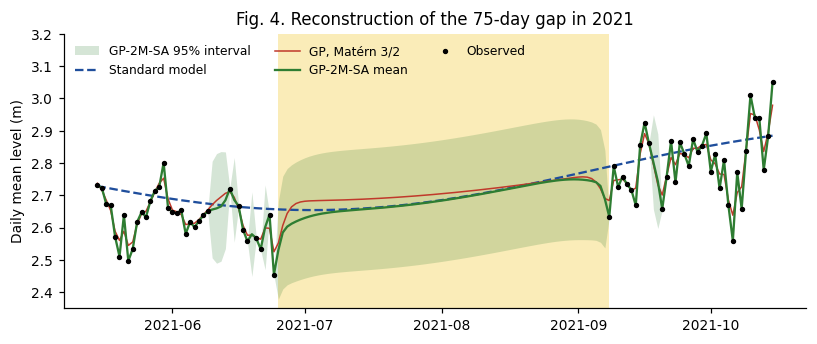

In [14]:
w0, w1 = pd.Timestamp('2021-05-15'), pd.Timestamp('2021-10-15')
sel = (idx_d >= w0) & (idx_d <= w1); ts_w = t_all[sel]
m2, sd2 = fits['GP2M32SA'].predict(ts_w); m1, _ = fits['GP'].predict(ts_w)
fig, ax = plt.subplots(figsize=(7.5, 3.2))
ax.axvspan(pd.Timestamp('2021-06-25'), pd.Timestamp('2021-09-08'), color='#f7e08a', alpha=0.6, lw=0)
ax.fill_between(idx_d[sel], m2 - 1.96*sd2, m2 + 1.96*sd2, color=COL['GP-2M-SA'], alpha=0.2, lw=0, label='GP-2M-SA 95% interval')
ax.plot(idx_d[sel], st.predict(ts_w), '--', color=COL['St'], label='Standard model')
ax.plot(idx_d[sel], m1, color=COL['GP'], lw=1, label='GP, Matérn 3/2')
ax.plot(idx_d[sel], m2, color=COL['GP-2M-SA'], lw=1.5, label='GP-2M-SA mean')
ax.plot(idx_d[sel], y_all[sel], 'o', color='k', ms=2.5, label='Observed')
ax.set_ylabel('Daily mean level (m)'); ax.legend(ncol=3, frameon=False, loc='upper left', fontsize=8); ax.set_ylim(2.35, 3.2)
ax.set_title('Fig. 4. Reconstruction of the 75-day gap in 2021')
plt.tight_layout(); plt.show()

,RMSE_cm,R2
method,,
Tide + GP-2M-SA,14.904,0.965
Tide + St,14.920,0.965
Tide + Z0,18.200,0.947
LI (hourly),114.430,-1.110


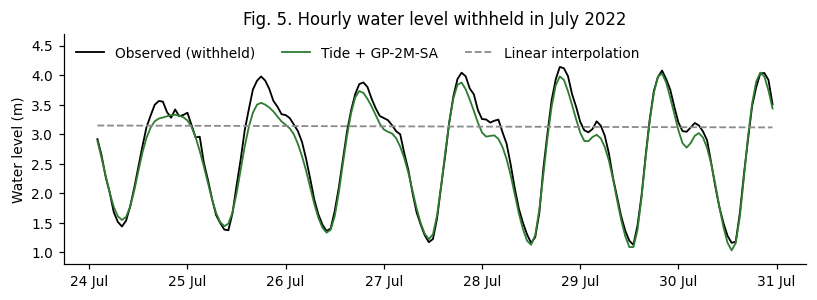

In [15]:
# Hourly validation on the ten realistic windows (C1 and C2): tide re-estimated without each window
def to_hourly(dser, hidx):
    s_ = dser.copy(); s_.index = s_.index + pd.Timedelta('12h')
    return s_.reindex(s_.index.union(hidx)).interpolate('time', limit_direction='both').reindex(hidx).values
hv_rows, example = [], None
for ci, (grp, lab, mask) in enumerate(CASES):
    if not grp.startswith('C'): continue
    days_w = idx_d[mask]; b0, b1 = days_w[0], days_w[-1] + pd.Timedelta('1D')
    inblk = (ho.index >= b0) & (ho.index < b1); hw = ho[inblk]
    c_ = tide_fit(ho.index[~inblk], ho.values[~inblk]); tide_w = tide_predict(hw.index, c_)
    base = daily.dmwl.where(~pd.Series(mask, idx_d)); pidx, pr = exp_preds[ci]
    rec = {'LI (hourly)': ho[~inblk].reindex(ho[~inblk].index.union(hw.index)).interpolate('time').reindex(hw.index).values,
           'Tide + Z0': tide_w + c_[0]}
    for name in ('St', 'GP-2M-SA'):
        s_ = base.copy(); s_.loc[pidx] = pr[name]; s_ = s_.loc[b0 - pd.Timedelta('3D'): b1 + pd.Timedelta('3D')]
        rec[f'Tide + {name}'] = tide_w + to_hourly(s_, hw.index)
    for k, v in rec.items():
        e = v - hw.values
        hv_rows.append({'window': lab, 'method': k, 'RMSE_cm': 100*np.sqrt(np.mean(e**2)), 'R2': 1 - np.sum(e**2)/np.sum((hw.values - hw.values.mean())**2)})
    if lab == '2022 Jun-Sep': example = pd.DataFrame({'obs': hw.values, **rec}, index=hw.index)
HV = pd.DataFrame(hv_rows)
display(HV.groupby('method')[['RMSE_cm', 'R2']].mean().sort_values('RMSE_cm').round(3))

ex = example.loc['2022-07-24':'2022-07-30']
fig, ax = plt.subplots(figsize=(7.5, 2.8))
ax.plot(ex.index, ex.obs, color='k', lw=1.2, label='Observed (withheld)')
ax.plot(ex.index, ex['Tide + GP-2M-SA'], color=COL['GP-2M-SA'], lw=1.2, label='Tide + GP-2M-SA')
ax.plot(ex.index, ex['LI (hourly)'], '--', color=COL['LI'], lw=1.2, label='Linear interpolation')
ax.set_ylabel('Water level (m)'); ax.set_ylim(0.8, 4.7); ax.legend(ncol=3, frameon=False, loc='upper left')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
ax.set_title('Fig. 5. Hourly water level withheld in July 2022')
plt.tight_layout(); plt.show()